<a href="https://colab.research.google.com/github/suyogbastakoti/Ai-and-Ml-Module/blob/main/2407093_SuyogBastakoti_Worksheet_3_Modelling_the_Neuron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 - Artificial Intelligence and Machine Learning
## Worksheet 3: Modeling the Neuron — From MCP to Perceptron

---

## Section 3: MCP Neurons

The McCulloch-Pitts (MCP) neuron is the first computational model of a biological neuron, proposed in 1943. It operates as a **linear threshold gate**: it sums binary inputs and fires (outputs 1) if the sum meets or exceeds a fixed threshold T, provided no inhibitory input is active.

### Task 1: Implementation of MCP Neurons

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### AND Gate using MCP Neuron

In [2]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements basic AND operations with MCP Neuron for two inputs.

    Arguments:
        X1 (list): An array of binary values.
        X2 (list): An array of binary values.
        T  (int) : Threshold value.

    Returns:
        state_neuron (list): State of neuron (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2), "Input arrays must have the same length."

    # Element-wise addition of the two input arrays
    summed_inputs = [X1[i] + X2[i] for i in range(len(X1))]

    # Apply threshold: output 1 if sum >= T, else 0
    state_neuron = []
    for s in summed_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage for AND gate
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2  # Both inputs must be 1 for AND to fire

result_and = MCP_Neurons_AND(X1, X2, T)
print(f"AND Gate (T={T})")
print(f"{'X1':>4} {'X2':>4} {'Output':>8}")
print("-" * 20)
for x1, x2, out in zip(X1, X2, result_and):
    print(f"{x1:>4} {x2:>4} {out:>8}")

AND Gate (T=2)
  X1   X2   Output
--------------------
   0    0        0
   0    1        0
   1    0        0
   1    1        1


#### OR Gate using MCP Neuron

In [3]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements basic OR operations with MCP Neuron for two inputs.

    Arguments:
        X1 (list): An array of binary values.
        X2 (list): An array of binary values.
        T  (int) : Threshold value.

    Returns:
        state_neuron (list): State of neuron (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2), "Input arrays must have the same length."

    # Element-wise addition of the two input arrays
    summed_inputs = [X1[i] + X2[i] for i in range(len(X1))]

    # Apply threshold: output 1 if sum >= T, else 0
    state_neuron = []
    for s in summed_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage for OR gate
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 1  # At least one input must be 1 for OR to fire

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"OR Gate (T={T})")
print(f"{'X1':>4} {'X2':>4} {'Output':>8}")
print("-" * 20)
for x1, x2, out in zip(X1, X2, result_or):
    print(f"{x1:>4} {x2:>4} {out:>8}")

OR Gate (T=1)
  X1   X2   Output
--------------------
   0    0        0
   0    1        1
   1    0        1
   1    1        1


### Question 1: Limitations of MCP Neurons

The MCP neuron has several fundamental limitations:

1. **Fixed, hand-crafted threshold**: The threshold T must be set manually by the designer. There is no learning mechanism to automatically determine the right threshold from data.

2. **No learnable weights**: All inputs are treated equally (weight = 1). The model cannot learn that some inputs are more important than others.

3. **Binary inputs only**: The MCP neuron only accepts binary (0 or 1) inputs. It cannot process continuous or real-valued data.

4. **Cannot solve non-linearly separable problems**: The MCP neuron can only implement functions that are linearly separable (e.g., AND, OR). It fails for XOR and other non-linear problems.

5. **No bias term**: Without a bias, the decision boundary is forced to pass through the origin, limiting the range of functions it can represent.

6. **Inhibitory inputs are all-or-nothing**: Any inhibitory input immediately suppresses the output to 0, regardless of other inputs — a very rigid mechanism.

7. **No adaptation / learning**: The model cannot improve itself from experience. It requires complete human design of the logic.

### Question 2: Can XOR be solved with a single MCP Neuron?

**No — XOR cannot be solved by a single MCP Neuron.**

The XOR truth table is:

| X1 | X2 | XOR Output |
|----|----|------------|
|  0 |  0 |     0      |
|  0 |  1 |     1      |
|  1 |  0 |     1      |
|  1 |  1 |     0      |

XOR is **not linearly separable** — no single straight line can divide the 0-output cases from the 1-output cases. Since the MCP neuron computes a simple weighted sum and compares it to a threshold, it can only implement linear decision boundaries.

**To implement XOR with MCP neurons**, we need a *network* of at least two layers:
- Layer 1: Compute `(X1 OR X2)` and `NOT (X1 AND X2)` separately
- Layer 2: AND the two results together
- i.e., `XOR(X1, X2) = AND(OR(X1,X2), NOT(AND(X1,X2)))`

This illustrates why multi-layer networks (and eventually deep learning) were needed to overcome this limitation.

In [4]:
# Demonstrating XOR with a 2-layer MCP network
def MCP_XOR_network(X1, X2):
    """
    Implements XOR using a two-layer network of MCP neurons.
    XOR(X1, X2) = AND( OR(X1,X2), NOT(AND(X1,X2)) )
    """
    results = []
    for x1, x2 in zip(X1, X2):
        # Layer 1a: OR gate (T=1)
        or_out = 1 if (x1 + x2) >= 1 else 0
        # Layer 1b: AND gate (T=2), then NOT it
        nand_out = 0 if (x1 + x2) >= 2 else 1  # NAND
        # Layer 2: AND the two outputs (T=2)
        xor_out = 1 if (or_out + nand_out) >= 2 else 0
        results.append(xor_out)
    return results

X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
xor_result = MCP_XOR_network(X1, X2)

print("XOR via 2-layer MCP Network")
print(f"{'X1':>4} {'X2':>4} {'XOR Output':>12}")
print("-" * 24)
for x1, x2, out in zip(X1, X2, xor_result):
    print(f"{x1:>4} {x2:>4} {out:>12}")

XOR via 2-layer MCP Network
  X1   X2   XOR Output
------------------------
   0    0            0
   0    1            1
   1    0            1
   1    1            0


---
## Section 4: The Perceptron

The Perceptron, introduced by Frank Rosenblatt in 1958, improves on the MCP neuron by adding **learnable weights** and an **adaptive learning process**. It is a Linear Binary Classifier that finds a decision boundary from training data automatically.

### Task 2: Perceptron Algorithm for 0 vs 1 Classification

#### Step 1: Load the Dataset

In [7]:
# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/Data Set /mnist_0_and_1.csv");

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixel features
y = df_0_1["label"].values                 # Labels (0 or 1)

print("Feature matrix shape:", X.shape)
print("Label vector shape:  ", y.shape)
print("Unique labels:", np.unique(y))
print(f"Class distribution — 0s: {np.sum(y==0)}, 1s: {np.sum(y==1)}")

Feature matrix shape: (12665, 784)
Label vector shape:   (12665,)
Unique labels: [0 1]
Class distribution — 0s: 5923, 1s: 6742


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Question 1: What does the shape of X represent?

`X.shape` returns `(n_samples, 784)` — where:
- **n_samples** is the total number of digit images in the dataset.
- **784** is the number of pixel features per image (28 × 28 pixels flattened into a single row vector).

Each row in X is one image, and each column is one pixel value.

#### Question 2: What does the shape of y represent?

`y.shape` returns `(n_samples,)` — a 1D array containing the true class label (0 or 1) for each corresponding image in X. It tells the model which digit each image actually shows.

#### Step 2: Visualize the Dataset

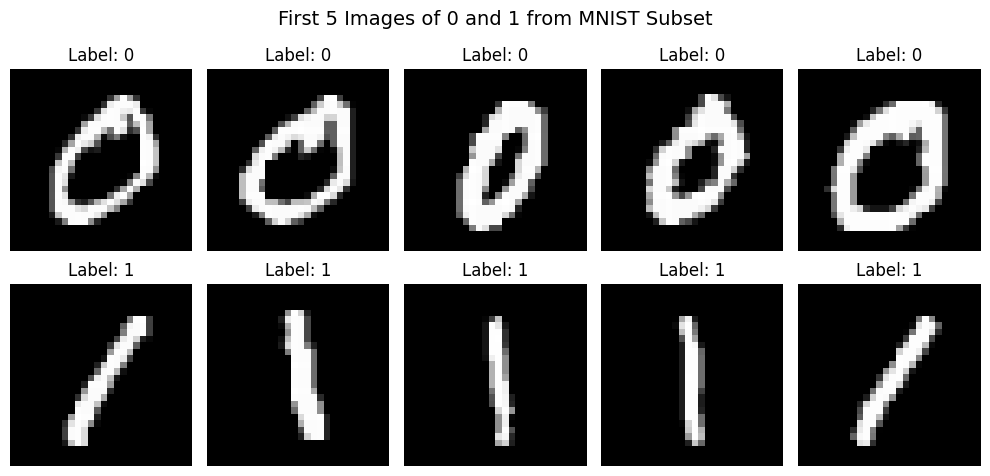

In [8]:
# Separate images by label
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset", fontsize=14)
plt.tight_layout()
plt.show()

#### Step 3: Initialize Weights and Bias

In [9]:
# Initialize weights and bias
weights       = np.zeros(X.shape[1])  # 784 weights (one per pixel)
bias          = 0
learning_rate = 0.1
epochs        = 100

print(f"Weights shape: {weights.shape}")
print(f"Bias:          {bias}")
print(f"Learning rate: {learning_rate}")
print(f"Epochs:        {epochs}")

Weights shape: (784,)
Bias:          0
Learning rate: 0.1
Epochs:        100


#### Question 3: What does the weights array represent?

The `weights` array has one value per pixel (784 values). Each weight represents **how important that pixel is** for making a classification decision. A large positive weight means that pixel strongly suggests class 1; a large negative weight means it strongly suggests class 0. Initially all weights are zero — the model has no prior knowledge.

#### Question 4: Why initialize weights to zero? What effect could this have?

Initializing weights to zero is a simple, neutral starting point — the model makes no assumptions. For a perceptron this is acceptable because the update rule is error-driven: as long as there are misclassifications, the weights will diverge from zero and learn meaningful values.

However, zero initialization has a subtle issue: on the very first pass all samples produce the same prediction (0), so all weights update in the same direction simultaneously. This is not a major problem for a single perceptron, but in deeper networks it causes the **symmetry problem** where all neurons learn identical features — which is why random initialization is preferred there.

#### Step 4: Implement the Decision (Activation) Function

In [10]:
def decision_function(X, weights, bias):
    """
    Compute predicted labels for input data using a step (threshold) activation.

    Parameters:
        X       : numpy array of shape (n_samples, n_features)
        weights : numpy array of shape (n_features,)
        bias    : scalar

    Returns:
        y_pred_all : numpy array of predicted labels (0 or 1)
    """
    # Compute weighted sum for all samples at once
    predictions = np.dot(X, weights) + bias

    # Step (threshold) activation function: output 1 if >= 0, else 0
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all


# Quick sanity check with zero weights (all predictions should be 1, since 0 >= 0)
test_preds = decision_function(X[:5], weights, bias)
print("Sample predictions (with zero weights):", test_preds)

Sample predictions (with zero weights): [1 1 1 1 1]


#### Step 5: Implement the Perceptron Learning Algorithm

In [12]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
        X             : numpy array (n_samples, n_features) — input features
        y             : numpy array (n_samples,)            — true labels
        weights       : numpy array (n_features,)           — initial weights
        bias          : scalar                              — initial bias
        learning_rate : float                               — step size for updates
        epochs        : int                                 — max training iterations

    Returns:
        weights  : updated weight array
        bias     : updated bias
        accuracy : float — accuracy on training set after final epoch
    """
    n_samples = X.shape[0]

    for epoch in range(epochs):
        convergence_flag = True  # Assume converged until a mistake is found

        for i in range(n_samples):
            # Step 1: Compute weighted sum
            output = np.dot(X[i], weights) + bias

            # Step 2: Apply step activation function
            y_pred = 1 if output >= 0 else 0

            # Step 3: Update weights only if prediction is wrong
            if y_pred != y[i]:
                error = y[i] - y_pred
                weights = weights + learning_rate * error * X[i]
                bias    = bias    + learning_rate * error
                convergence_flag = False  # At least one update occurred

        # Early stopping: if no updates in this epoch, we have converged
        if convergence_flag:
            print(f"Converged at epoch {epoch + 1}")
            break

    # Compute final training accuracy
    final_preds = decision_function(X, weights, bias)
    accuracy    = np.mean(final_preds == y)

    return weights, bias, accuracy

#### Question 5: What does `output = np.dot(X[i], weights) + bias` do?

This line computes the **net input** (weighted sum) for sample `i`. `np.dot(X[i], weights)` multiplies each pixel value by its corresponding weight and sums them all up — this is the dot product. Adding `bias` shifts the decision boundary away from the origin. The result `output` (also written as `z`) is then passed to the activation function to produce a prediction.

#### Question 6: What happens when the prediction is wrong?

When `y_pred != y[i]`, the **perceptron learning rule** fires:
- `error = y[i] - y_pred` → this is +1 (predicted 0, truth 1) or -1 (predicted 1, truth 0)
- **Weight update**: `w = w + η × error × x` — each weight is nudged in the direction that would push the weighted sum toward the correct output.
- **Bias update**: `b = b + η × error` — the bias is adjusted similarly, shifting the decision boundary.

If the prediction is *correct*, no update happens and the weights stay the same.

#### Question 7: Why is final accuracy important, and what do we expect?

Final accuracy tells us how well the perceptron has learned to separate the two classes on its training data. Since digits 0 and 1 are **very visually distinct** (different pixel patterns with good linear separability), we expect the perceptron to achieve **close to 100% accuracy** on this dataset — demonstrating that the Perceptron Convergence Theorem guarantees convergence for linearly separable data.

#### Step 6: Train the Perceptron

In [13]:
# Re-initialize weights and bias before training
weights       = np.zeros(X.shape[1])
bias          = 0
learning_rate = 0.1
epochs        = 100

# Train the perceptron
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)

print(f"\nFinal Training Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Converged at epoch 13

Final Training Accuracy: 1.0000 (100.00%)


#### Step 7: Visualize Misclassified Images

In [14]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred      = np.where(predictions >= 0, 1, 0)

# Final accuracy check
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Visualize misclassified images
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    n_show = min(10, len(misclassified_idx))
    n_cols = 5
    n_rows = (n_show + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
    axes = np.array(axes).flatten()
    for ax, idx in zip(axes, misclassified_idx[:n_show]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    for ax in axes[n_show:]:
        ax.axis("off")
    plt.suptitle(f"Misclassified Images — 0 vs 1 ({len(misclassified_idx)} total)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


#### Question 8: What does `misclassified_idx` store, and how is it used?

`misclassified_idx` stores the **integer indices** (row positions) of all samples where the model's prediction `y_pred[i]` does not match the true label `y[i]`. `np.where(y_pred != y)[0]` scans the entire label array and returns positions wherever the condition is True.

It is used to index back into `X` (the image array) to retrieve and display the actual pixel data for those wrongly-classified images, allowing us to visually inspect which images confused the perceptron.

#### Question 9: How to interpret "All images were correctly classified!"?

This means the perceptron has **converged perfectly** on the training data — it found a linear decision boundary that separates every 0 from every 1 in the dataset with zero errors. This is expected for 0 vs 1 classification because the two digits are visually very different and their pixel representations are linearly separable. It confirms the **Perceptron Convergence Theorem**: if data is linearly separable, the perceptron is guaranteed to find a perfect solution in a finite number of steps.

---
## Task 3: Perceptron Algorithm for 3 vs 5 Classification

Now we repeat the same pipeline for the more challenging problem of classifying digit 3 vs digit 5. These digits share similar curved shapes, making them harder to separate linearly.

#### Step 1: Load the Dataset

In [15]:
# Load the 3 vs 5 dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/Data Set /mnist_3_and_5.csv")

# Extract features and labels
X2 = df_3_5.drop(columns=["label"]).values
y2 = df_3_5["label"].values

print("Feature matrix shape:", X2.shape)
print("Label vector shape:  ", y2.shape)
print("Unique labels:", np.unique(y2))
print(f"Class distribution — 3s: {np.sum(y2==3)}, 5s: {np.sum(y2==5)}")

Feature matrix shape: (2741, 784)
Label vector shape:   (2741,)
Unique labels: [3 5]
Class distribution — 3s: 1484, 5s: 1257


#### Step 2: Visualize the Dataset

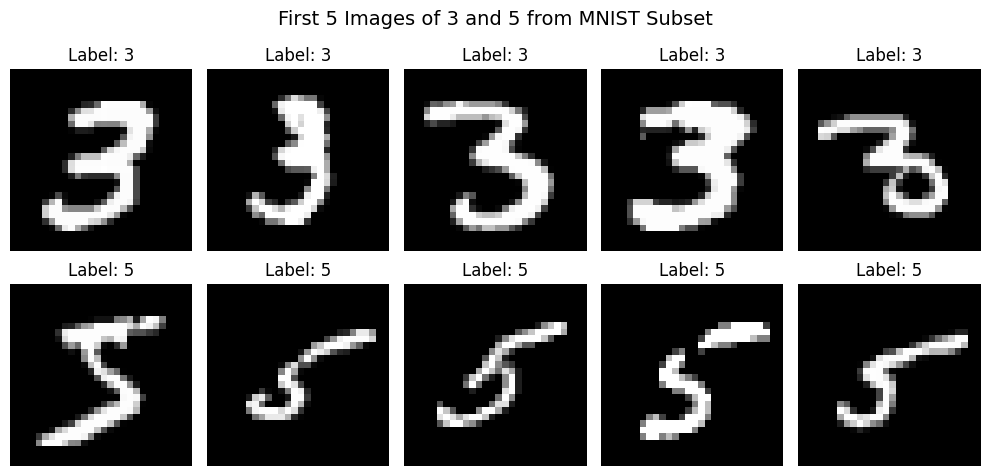

In [16]:
images_3 = X2[y2 == 3]
images_5 = X2[y2 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images to plot.")
else:
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset", fontsize=14)
plt.tight_layout()
plt.show()

#### Step 3: Initialize Weights and Bias

In [17]:
# The perceptron needs binary labels (0 and 1), so we remap: 3 → 0, 5 → 1
y2_binary = np.where(y2 == 5, 1, 0)

weights2       = np.zeros(X2.shape[1])
bias2          = 0
learning_rate2 = 0.1
epochs2        = 100

print(f"Weights shape: {weights2.shape}")
print(f"Bias:          {bias2}")
print(f"Label mapping: 3 → 0, 5 → 1")

Weights shape: (784,)
Bias:          0
Label mapping: 3 → 0, 5 → 1


#### Step 4 & 5: Train the Perceptron

In [18]:
weights2, bias2, accuracy2 = train_perceptron(
    X2, y2_binary, weights2, bias2, learning_rate2, epochs2
)

print(f"\nFinal Training Accuracy (3 vs 5): {accuracy2:.4f} ({accuracy2*100:.2f}%)")


Final Training Accuracy (3 vs 5): 0.9869 (98.69%)


#### Step 6: Visualize Misclassified Images

Final Accuracy (3 vs 5): 0.9869


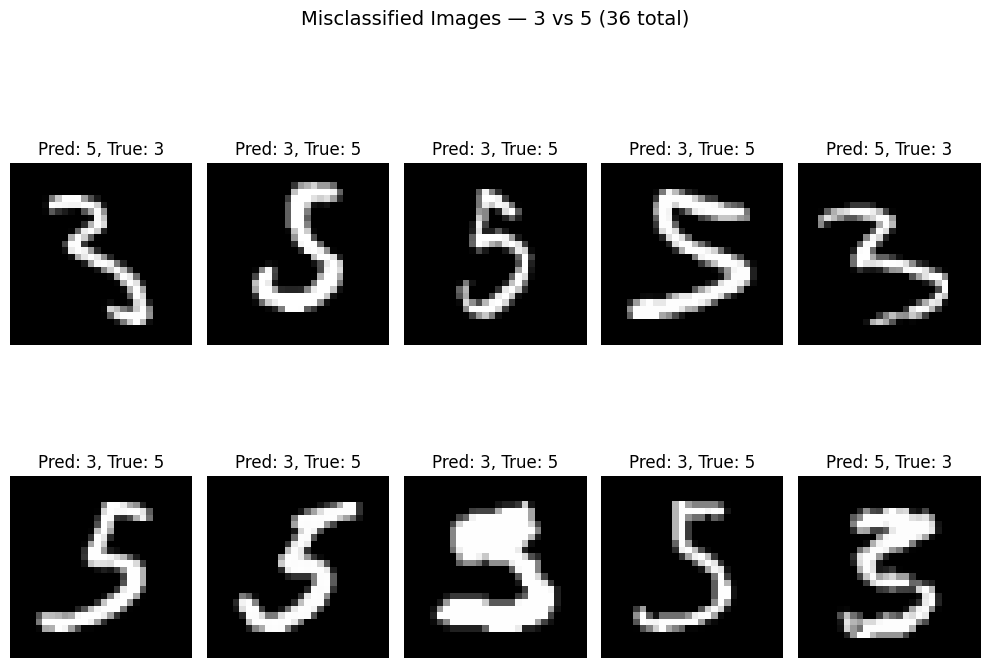

In [19]:
# Get predictions for all data points
predictions2 = np.dot(X2, weights2) + bias2
y2_pred      = np.where(predictions2 >= 0, 1, 0)

# Map binary predictions back to original labels for display
y2_pred_labels = np.where(y2_pred == 1, 5, 3)

final_accuracy2 = np.mean(y2_pred == y2_binary)
print(f"Final Accuracy (3 vs 5): {final_accuracy2:.4f}")

misclassified_idx2 = np.where(y2_pred != y2_binary)[0]

if len(misclassified_idx2) > 0:
    n_show = min(10, len(misclassified_idx2))
    n_cols = 5
    n_rows = (n_show + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
    axes = np.array(axes).flatten()
    for ax, idx in zip(axes, misclassified_idx2[:n_show]):
        ax.imshow(X2[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y2_pred_labels[idx]}, True: {y2[idx]}")
        ax.axis("off")
    for ax in axes[n_show:]:
        ax.axis("off")
    plt.suptitle(f"Misclassified Images — 3 vs 5 ({len(misclassified_idx2)} total)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

### Conclusion: 3 vs 5 Classification

**Observations:**

- The perceptron achieves **lower accuracy** on the 3 vs 5 task compared to the 0 vs 1 task. This is expected.
- Digits **3 and 5 share very similar visual features**: both have curved tops and open middles. Many handwritten samples are genuinely ambiguous even to a human glancing quickly.
- The misclassified images typically show **ambiguously written digits** — a 3 written in a style resembling a 5, or vice versa.

**Why does the perceptron struggle?**

1. **Limited linear separability**: Unlike 0 vs 1, the pixel-space representations of 3 and 5 overlap significantly. No single hyperplane cleanly separates all examples.
2. **High intra-class variation**: Handwritten digits vary widely — some 3s look like 5s and vice versa.
3. **The perceptron's fundamental limitation**: It can only learn a **linear decision boundary**. When data is not linearly separable, it cannot converge to zero error.

**What this suggests:**

To improve performance on visually similar digits, we would need:
- **Multi-layer networks (MLPs)** — to learn non-linear decision boundaries.
- **Convolutional Neural Networks (CNNs)** — to exploit spatial structure in image data.
- **Feature engineering** — e.g., using edges or shapes rather than raw pixels.